##### 1. Load Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

##### 2. Load and Add Target Columns (normalized from preprocessing notebook)
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# dictionary for value insertion for target column
targets = {
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def read_all_csvs_to_df(folder_path):
    dataframes = []

    file_list = sorted(f for f in os.listdir(folder_path) if f.endswith(".csv"))

    for i, file_name in enumerate(file_list):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path, header=None)

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key in file_name), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        dataframes.append(df.assign(target=target_value))

    combined_df = pd.concat(dataframes, ignore_index=True)

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
folder_path = os.path.join("..", "data", "mixed_ratio")
df = read_all_csvs_to_df(folder_path)

# for testing
#print(df.head())

C:\Users\jaira\AppData\Local\Temp\ipykernel_21172\3008409842.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataframes.append(df.assign(target=target_value))
C:\Users\jaira\AppData\Local\Temp\ipykernel_21172\3008409842.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])


##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
def label_data(dataframe):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df

clean_df = label_data(df)

#for testing
#print(clean_df.head())
#df.to_csv("file_bad.csv")

##### 4. Implement PCA

In [ ]:
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})

print("Imports complete.")


def run_pca_spectral_style(
    dataframe,
    target_col="target_encoded",
    n_components=10,
    top_n=15,
    five_points_per_group=False,
    show_point_labels=False,
    save_prefix=None         # e.g. "Fig4_PCA"
):
    if target_col not in dataframe.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    # ── Split features / labels ────────────────────────────────────────────────
    feature_cols = [c for c in dataframe.columns if c != target_col]
    X = dataframe[feature_cols].to_numpy()
    y = dataframe[target_col].to_numpy()

    # ── JSON Mapping for species names ────────────────────────────────────────────────
    with open(os.path.join(os.getcwd(), "target_encoding_map.json"), "r") as f:
        target_map_raw = json.load(f)

    # reverse mapping: {"label": 0} -> {0: "label"}
    target_map = {v: k for k, v in target_map_raw.items()}

    sample_labels = [target_map[val] for val in y]

    # ── Standardise ────────────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # ── PCA fit ────────────────────────────────────────────────────────────────
    n_components = min(n_components, X_std.shape[0], X_std.shape[1])
    pca = PCA(n_components=n_components)

    scores = pca.fit_transform(X_std)
    loadings = pca.components_
    ev = pca.explained_variance_ratio_

    print("Explained variance per PC:")
    for i, v in enumerate(ev[:5]):
        print(f"  PC{i+1}: {v*100:.2f}%")
    if len(ev) >= 2:
        print(f"  PC1+PC2 combined: {sum(ev[:2])*100:.1f}%")

    # ── PCA score dataframe ───────────────────────────────────────────────────
    pca_df = pd.DataFrame(
        scores[:, :2],
        columns=["PC1", "PC2"]
    )
    pca_df[target_col] = y
    pca_df["sample_label"] = sample_labels

    # ── Feature labels for loading plot ───────────────────────────────────────
    # If spectral columns are numeric wavenumbers, use them; otherwise use names
    try:
        feature_axis_labels = np.array([float(c) for c in feature_cols])
        feature_axis_is_numeric = True
    except:
        feature_axis_labels = np.array(feature_cols)
        feature_axis_is_numeric = False

    # ── Styling maps for groups ────────────────────────────────────────────────
    unique_groups = list(dict.fromkeys(y))

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    color_cycle = [
        "#2166AC", "#4DAF4A", "#FF7F00", "#984EA3", "#A65628",
        "#E41A1C", "#17BECF", "#BCBD22", "#7F7F7F", "#1F77B4"
    ]

    group_markers = {
        grp: marker_cycle[i % len(marker_cycle)]
        for i, grp in enumerate(unique_groups)
    }
    group_colors = {
        grp: color_cycle[i % len(color_cycle)]
        for i, grp in enumerate(unique_groups)
    }

    # ── Figure layout ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    # ── PCA score plot ─────────────────────────────────────────────────────────
    ax = axes[0]
    for grp in unique_groups:
        idx = np.where(y == grp)[0]

        if five_points_per_group:
            idx_to_plot = idx[:5]   # only first sample from each group
        else:
            idx_to_plot = idx       # plot all samples

        sc = scores[idx_to_plot, :2]

        ax.scatter(
            sc[:, 0],
            sc[:, 1],
            c=group_colors.get(grp, "#888888"),
            s=90,
            marker=group_markers.get(grp, "o"),
            edgecolors="white",
            linewidths=0.5,
            zorder=3,
            label=target_map.get(grp, str(grp)),
        )

        if show_point_labels:
            for i in idx_to_plot:
                ax.annotate(
                    sample_labels[i],
                    (scores[i, 0], scores[i, 1]),
                    xytext=(5, 3),
                    textcoords="offset points",
                    fontsize=6.5,
                    color=group_colors.get(grp, "#888888"),
                )

        ax.axhline(0, color="gray", lw=0.5, ls="--")
        ax.axvline(0, color="gray", lw=0.5, ls="--")
        ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
        ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
        ax.set_title("PCA Scores — PC1 vs PC2\n(Five Points per Group)")
        ax.legend(fontsize=8)
    
    ax.legend(
    title="Ratio | Species",
    fontsize=8,
    title_fontsize=9,
    loc="best"
    )

    # ── Top loading contributors plot ─────────────────────────────────────────
    ax2 = axes[1]
    top_n = min(top_n, loadings.shape[1])

    comb = np.abs(loadings[0]) + np.abs(loadings[1])
    top_idx = np.argsort(comb)[::-1][:top_n]

    top_features = feature_axis_labels[top_idx]
    lpc1 = loadings[0][top_idx]
    lpc2 = loadings[1][top_idx]
    ypos = np.arange(top_n)

    ax2.barh(ypos - 0.2, lpc1, height=0.35, color="#2166AC", alpha=0.8, label="PC1")
    ax2.barh(ypos + 0.2, lpc2, height=0.35, color="#E41A1C", alpha=0.8, label="PC2")

    ax2.set_yticks(ypos)
    if feature_axis_is_numeric:
        ax2.set_yticklabels([f"{w:.0f}" for w in top_features], fontsize=8)
        ax2.set_title(f"Top {top_n} Spectral Variables by |PC1| + |PC2| Loading")
    else:
        ax2.set_yticklabels([str(w) for w in top_features], fontsize=8)
        ax2.set_title(f"Top {top_n} Features by |PC1| + |PC2| Loading")

    ax2.axvline(0, color="black", lw=0.8)
    ax2.set_xlabel("Loading coefficient")
    ax2.legend(fontsize=9)
    ax2.invert_yaxis()

    plt.suptitle("PCA — Spectral Clustering", fontsize=12, fontweight="bold")
    plt.tight_layout()

    """if save_prefix is not None:
        plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
        plt.savefig(f"{save_prefix}.png", dpi=200, bbox_inches="tight")"""

    plt.show()

    return {
        "pca_df": pca_df,
        "pca_model": pca,
        "scaler": scaler,
        "scores": scores,
        "loadings": loadings,
        "explained_variance_ratio": ev,
        "feature_columns": feature_cols,
    }

Imports complete.


##### 5. Visualize the PCA

Explained variance per PC:
  PC1: 36.23%
  PC2: 18.33%
  PC3: 9.19%
  PC4: 6.11%
  PC5: 3.76%
  PC1+PC2 combined: 54.6%


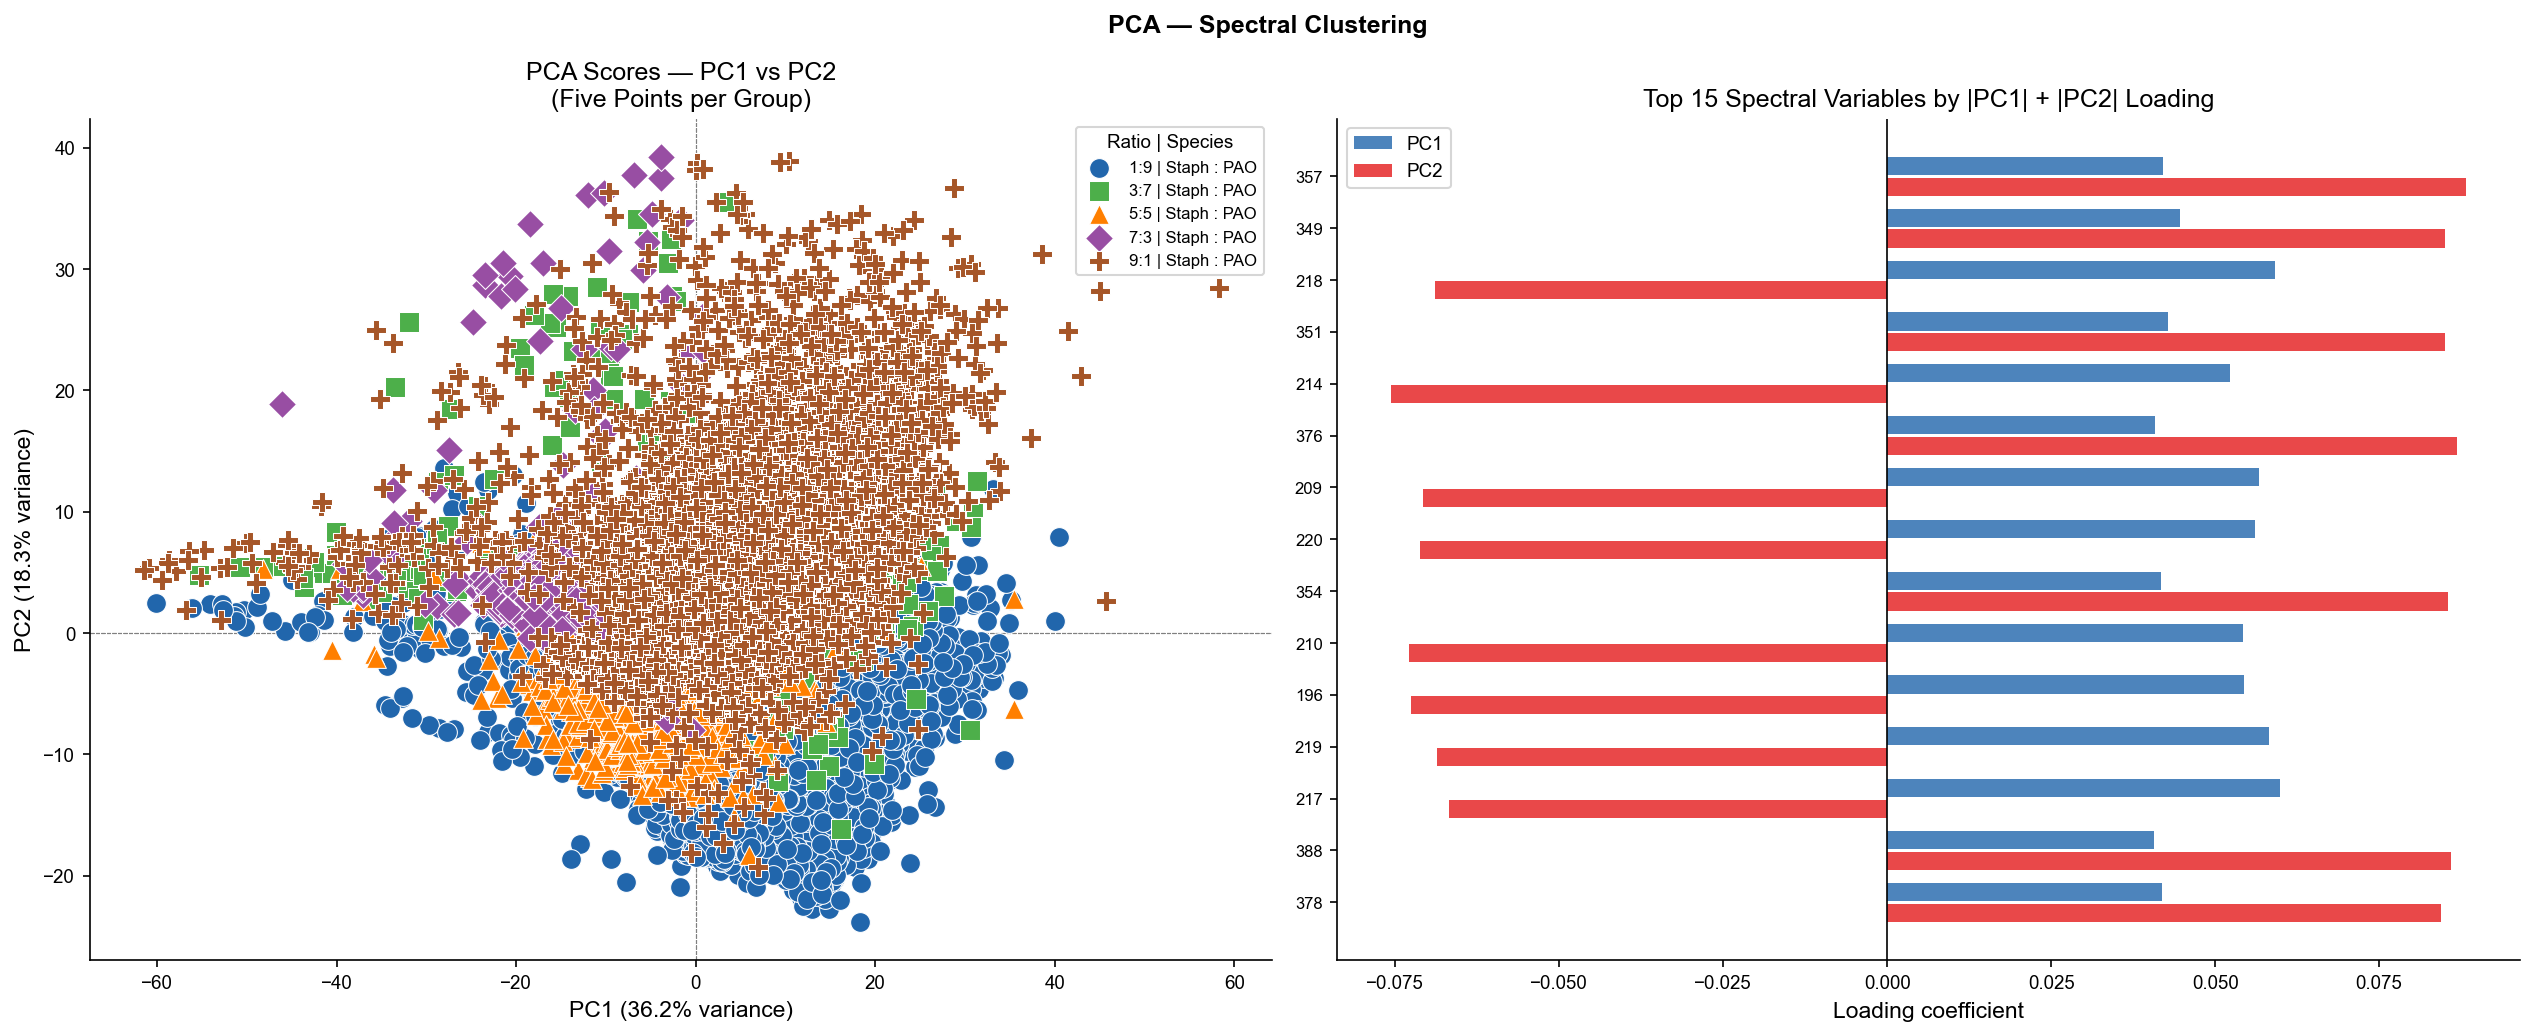

In [5]:
results = run_pca_spectral_style(
    clean_df,
    target_col="target_encoded",
    n_components=10,
    top_n=15,
    save_prefix=None,
    five_points_per_group=False
)

pca_df = results["pca_df"]
pca_model = results["pca_model"]
pca_scaler = results["scaler"]